In [5]:
import pandas as pd

In [6]:
dataset = pd.read_csv("Social_Network_Ads.csv")

In [7]:
dataset

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [8]:
dataset = pd.get_dummies(dataset, dtype=int, drop_first=True)

In [9]:
dataset

,User ID,Age,EstimatedSalary,Purchased,Gender_Male
0,15624510,19,19000,0,1
1,15810944,35,20000,0,1
2,15668575,26,43000,0,0
3,15603246,27,57000,0,0
4,15804002,19,76000,0,1
...,...,...,...,...,...
395,15691863,46,41000,1,0
396,15706071,51,23000,1,1
397,15654296,50,20000,1,0
398,15755018,36,33000,0,1


In [10]:
dataset.columns

Index(['User ID', 'Age', 'EstimatedSalary', 'Purchased', 'Gender_Male'], dtype='object')

In [11]:
independent = dataset[['User ID', 'Age', 'EstimatedSalary', 'Gender_Male']]

In [12]:
independent

,User ID,Age,EstimatedSalary,Gender_Male
0,15624510,19,19000,1
1,15810944,35,20000,1
2,15668575,26,43000,0
3,15603246,27,57000,0
4,15804002,19,76000,1
...,...,...,...,...
395,15691863,46,41000,0
396,15706071,51,23000,1
397,15654296,50,20000,0
398,15755018,36,33000,1


In [13]:
dependent = dataset[['Purchased']]

In [14]:
dependent

,Purchased
0,0
1,0
2,0
3,0
4,0
...,...
395,1
396,1
397,1
398,0


In [15]:
from sklearn.model_selection import train_test_split

In [16]:
x_train, x_test, y_train, y_test = train_test_split(independent, dependent, test_size=0.30, random_state=0)

In [17]:
x_train

,User ID,Age,EstimatedSalary,Gender_Male
92,15809823,26,15000,1
223,15593715,60,102000,1
234,15619407,38,112000,0
232,15813113,40,107000,1
377,15800215,42,53000,0
...,...,...,...,...
323,15619465,48,30000,0
192,15779581,29,43000,1
117,15591433,36,52000,1
47,15776348,27,54000,0


In [18]:
y_train

,Purchased
92,0
223,1
234,0
232,1
377,0
...,...
323,1
192,0
117,0
47,0


In [19]:
x_test

,User ID,Age,EstimatedSalary,Gender_Male
132,15725660,30,87000,1
309,15652400,38,50000,0
341,15776844,35,75000,1
196,15738448,30,79000,0
246,15638003,35,50000,0
...,...,...,...,...
216,15636023,49,65000,1
259,15815236,45,131000,0
49,15793813,31,89000,0
238,15617877,46,82000,0


In [20]:
y_test

,Purchased
132,0
309,0
341,0
196,0
246,0
...,...
216,0
259,1
49,0
238,0


In [21]:
#Model Creation code for DecisionTree Classification

In [22]:
from sklearn.tree import DecisionTreeClassifier

In [25]:
Classifier = DecisionTreeClassifier(criterion='entropy',splitter='random',max_features='log2')

In [26]:
Classifier = Classifier.fit(x_train,y_train)

In [27]:
#Code to see how the tree is plotted

In [28]:
import matplotlib.pyplot as plt

In [29]:
from sklearn import tree

[Text(0.5915743670886076, 0.9642857142857143, 'x[2] <= 88827.183\nentropy = 0.946\nsamples = 280\nvalue = [178, 102]'),
 Text(0.37776898734177217, 0.8928571428571429, 'x[2] <= 61389.853\nentropy = 0.772\nsamples = 212\nvalue = [164, 48]'),
 Text(0.4846716772151899, 0.9285714285714286, 'True  '),
 Text(0.2555379746835443, 0.8214285714285714, 'x[2] <= 50248.92\nentropy = 0.833\nsamples = 125\nvalue = [92, 33]'),
 Text(0.1819620253164557, 0.75, 'x[1] <= 26.26\nentropy = 0.956\nsamples = 85\nvalue = [53, 32]'),
 Text(0.16930379746835442, 0.6785714285714286, 'entropy = 0.0\nsamples = 21\nvalue = [21, 0]'),
 Text(0.19462025316455697, 0.6785714285714286, 'x[0] <= 15737049.827\nentropy = 1.0\nsamples = 64\nvalue = [32, 32]'),
 Text(0.08544303797468354, 0.6071428571428571, 'x[0] <= 15627358.151\nentropy = 0.984\nsamples = 47\nvalue = [20.0, 27.0]'),
 Text(0.02531645569620253, 0.5357142857142857, 'x[1] <= 38.608\nentropy = 0.896\nsamples = 16\nvalue = [5, 11]'),
 Text(0.012658227848101266, 0.464

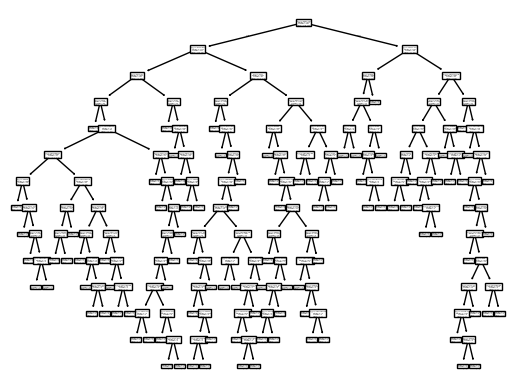

In [30]:
tree.plot_tree(Classifier)

In [31]:
plt.show()

In [32]:
y_pred = Classifier.predict(x_test)

In [33]:
#Evaluation Metrics for Decision Tree Classifier

In [34]:
from sklearn.metrics import confusion_matrix

In [35]:
cm = confusion_matrix(y_test, y_pred)

In [36]:
cm

array([[70,  9],
       [11, 30]])

In [37]:
from sklearn.metrics import classification_report

In [38]:
clf_report = classification_report(y_test, y_pred)

In [40]:
print(clf_report)

              precision    recall  f1-score   support

           0       0.86      0.89      0.88        79
           1       0.77      0.73      0.75        41

    accuracy                           0.83       120
   macro avg       0.82      0.81      0.81       120
weighted avg       0.83      0.83      0.83       120

